# PyTorch MLPs — From a Single Neuron Upward

This notebook builds from the ground up: a single neuron by hand, then manual backprop, then `nn.Module`, then full MLP training on MNIST.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
## 1. A Single Neuron — Pure Python

A neuron computes $z = \mathbf{w}^\top \mathbf{x} + b$, then applies an activation: $a = \phi(z)$.

We implement this with raw tensors and compute the gradient by hand to see exactly what PyTorch autograd is doing under the hood.

In [ ]:
# --- Forward pass ---
torch.manual_seed(0)
x = torch.tensor([0.5, -1.2, 0.8])  # input, shape (3,)
w = torch.randn(3, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

z = w @ x + b  # pre-activation (dot product + bias)
a = torch.tanh(z)  # activation
loss = (a - 1.0) ** 2  # toy MSE loss vs target 1.0

print(f"z={z.item():.4f}  a={a.item():.4f}  loss={loss.item():.4f}")

z=-0.6204  a=-0.5514  loss=2.4069


In [ ]:
# --- Backward pass via autograd ---
loss.backward()
print(f"dL/dw = {w.grad}")
print(f"dL/db = {b.grad}")

# --- Manual verification ---
# dL/da = 2(a - 1)
# da/dz = 1 - tanh(z)^2  (sech^2)
# dz/dw = x
dL_da = 2 * (a - 1.0)
da_dz = 1 - torch.tanh(z) ** 2
dz_dw = x
dL_dw_manual = (dL_da * da_dz * dz_dw).detach()
print(f"manual dL/dw = {dL_dw_manual}")
print(f"Match: {torch.allclose(w.grad, dL_dw_manual)}")

dL/dw = tensor([-1.0797,  2.5913, -1.7275])
dL/db = tensor([-2.1594])
manual dL/dw = tensor([-1.0797,  2.5913, -1.7275])
Match: True


---
## 2. Training a Single Neuron with Gradient Descent

Learn a scalar function $y = \sin(x)$ using a single neuron — just to see the training loop mechanics clearly before scaling up.

Final loss: 0.0803  (note: single neuron cannot fit sin(x) well)


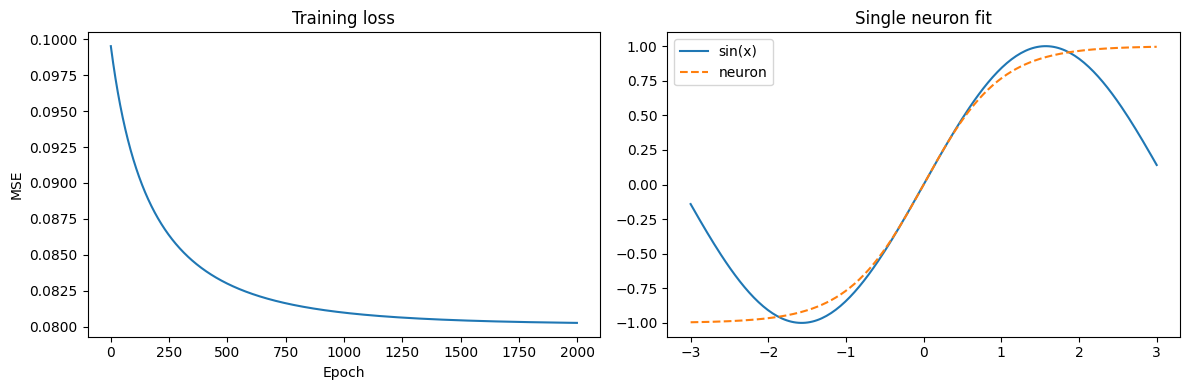

In [ ]:
X = torch.linspace(-3, 3, 200).unsqueeze(1)  # (200, 1)
y = torch.sin(X)

# Single neuron: 1 input, 1 output, no hidden layer
w = torch.randn(1, 1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)
lr = 0.01
losses = []

for epoch in range(2000):
    pred = torch.tanh(X @ w.T + b)  # (200, 1)
    loss = F.mse_loss(pred, y)
    loss.backward()
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad
    w.grad.zero_()
    b.grad.zero_()
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.4f}  (note: single neuron cannot fit sin(x) well)")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Training loss")
plt.subplot(1, 2, 2)
plt.plot(X.detach(), y.detach(), label="sin(x)")
plt.plot(X.detach(), pred.detach(), label="neuron", linestyle="--")
plt.legend()
plt.title("Single neuron fit")
plt.tight_layout()
plt.show()

---
## 3. Building Neurons and Layers with `nn.Module`

Now we replicate the single neuron as an `nn.Module`, then compose layers.

In [ ]:
class Neuron(nn.Module):
    """One neuron: scalar output, tanh activation."""

    def __init__(self, n_inputs):
        super().__init__()
        self.w = nn.Parameter(torch.randn(n_inputs))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return torch.tanh(x @ self.w + self.b)


class Layer(nn.Module):
    """A layer of neurons — equivalent to nn.Linear + activation."""

    def __init__(self, n_inputs, n_outputs, activation=torch.tanh):
        super().__init__()
        self.neurons = nn.ModuleList([Neuron(n_inputs) for _ in range(n_outputs)])
        self.activation = activation

    def forward(self, x):
        return torch.stack([n(x) for n in self.neurons], dim=-1)


class MLP(nn.Module):
    """Multi-layer perceptron built from our custom Layer."""

    def __init__(self, layer_sizes):
        super().__init__()
        self.layers = nn.ModuleList(
            [
                Layer(layer_sizes[i], layer_sizes[i + 1])
                for i in range(len(layer_sizes) - 1)
            ]
        )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


mlp = MLP([1, 16, 16, 1])
print(mlp)
print(f"Parameters: {sum(p.numel() for p in mlp.parameters()):,}")

MLP(
  (layers): ModuleList(
    (0-1): 2 x Layer(
      (neurons): ModuleList(
        (0-15): 16 x Neuron()
      )
    )
    (2): Layer(
      (neurons): ModuleList(
        (0): Neuron()
      )
    )
  )
)
Parameters: 321


Final loss: 0.000256


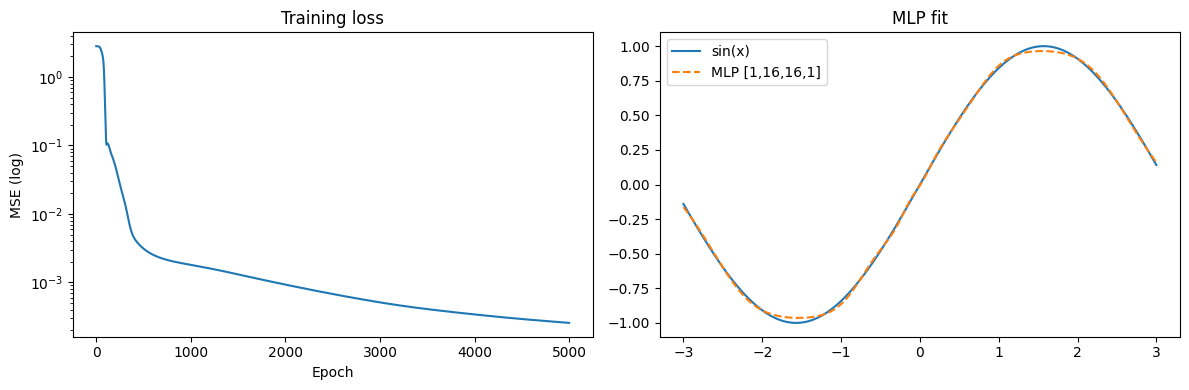

In [ ]:
# Fit sin(x) with our custom MLP
optimizer = optim.Adam(mlp.parameters(), lr=1e-3)
losses = []

for epoch in range(5000):
    pred = mlp(X)
    loss = F.mse_loss(pred.squeeze(), y.squeeze())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.6f}")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("MSE (log)")
plt.title("Training loss")
plt.subplot(1, 2, 2)
plt.plot(X.detach(), y.detach(), label="sin(x)")
plt.plot(X.detach(), pred.detach(), label="MLP [1,16,16,1]", linestyle="--")
plt.legend()
plt.title("MLP fit")
plt.tight_layout()
plt.show()

---
## 4. The Standard Way: `nn.Linear` and `nn.Sequential`

Our custom Layer is equivalent to `nn.Linear`. In practice we use the built-in modules which are faster and better tested.

In [ ]:
# nn.Linear wraps W (out x in) and b (out) with kaiming init
linear = nn.Linear(in_features=3, out_features=5)
print(f"Weight shape: {linear.weight.shape}")  # (5, 3)
print(f"Bias shape:   {linear.bias.shape}")  # (5,)

# Forward: y = x W^T + b
x = torch.randn(2, 3)  # batch of 2
print(f"Output shape: {linear(x).shape}")  # (2, 5)

Weight shape: torch.Size([5, 3])
Bias shape:   torch.Size([5])
Output shape: torch.Size([2, 5])


In [ ]:
# Build a clean MLP with nn.Sequential
def make_mlp(layer_sizes, dropout=0.0):
    layers = []
    for i in range(len(layer_sizes) - 1):
        layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
        if i < len(layer_sizes) - 2:  # no activation/dropout on output layer
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
    return nn.Sequential(*layers)


model = make_mlp([784, 256, 128, 10], dropout=0.3)
print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=128, out_features=10, bias=True)
)
Parameters: 235,146


---
## 5. Weight Initialization

Bad initialization leads to vanishing/exploding activations before training even starts. PyTorch defaults are good, but understanding them matters.

In [ ]:
def activation_stats(model, x):
    """Run x through model, print mean/std of each layer's output."""
    print(f"Input:     mean={x.mean():.3f} std={x.std():.3f}")
    for i, layer in enumerate(model):
        x = layer(x)
        print(
            f"Layer {i} ({layer.__class__.__name__}): mean={x.mean():.3f} std={x.std():.3f}"
        )


x = torch.randn(1000, 784)  # random batch

print("=== Default (Kaiming) init ===")
activation_stats(make_mlp([784, 256, 128, 64, 10]), x)

print("\n=== Bad init: large weights ===")
bad_model = make_mlp([784, 256, 128, 64, 10])
for p in bad_model.parameters():
    nn.init.normal_(p, std=2.0)
activation_stats(bad_model, x)

=== Default (Kaiming) init ===
Input:     mean=0.002 std=1.000
Layer 0 (Linear): mean=0.002 std=0.579
Layer 1 (ReLU): mean=0.232 std=0.339
Layer 2 (Linear): mean=-0.011 std=0.232
Layer 3 (ReLU): mean=0.087 std=0.131
Layer 4 (Linear): mean=-0.021 std=0.106
Layer 5 (ReLU): mean=0.033 std=0.054
Layer 6 (Linear): mean=0.009 std=0.067

=== Bad init: large weights ===
Input:     mean=0.002 std=1.000
Layer 0 (Linear): mean=0.065 std=56.288
Layer 1 (ReLU): mean=22.471 std=32.882
Layer 2 (Linear): mean=-14.112 std=1273.501
Layer 3 (ReLU): mean=501.052 std=723.190
Layer 4 (Linear): mean=-2383.822 std=20162.721
Layer 5 (ReLU): mean=6831.343 std=11173.828
Layer 6 (Linear): mean=20582.240 std=163764.984


**Kaiming (He) initialization** sets $\text{std} = \sqrt{2/n_{\text{in}}}$ for ReLU networks, chosen so that the variance of activations is preserved across layers:

$$\text{Var}(h^{(\ell)}) = \text{Var}(h^{(\ell-1)}) \quad \Rightarrow \quad \text{Var}(w) = \frac{2}{n_{\text{in}}}$$

The factor of 2 accounts for ReLU zeroing half the distribution.

---
## 6. Batch Normalization and Dropout

In [ ]:
class MLPWithBatchNorm(nn.Module):
    def __init__(self, layer_sizes, dropout=0.3):
        super().__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            if i < len(layer_sizes) - 2:
                layers.append(
                    nn.BatchNorm1d(layer_sizes[i + 1])
                )  # normalize over batch
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


model_bn = MLPWithBatchNorm([784, 256, 128, 10])
print(model_bn)
print(f"Parameters: {sum(p.numel() for p in model_bn.parameters()):,}")

MLPWithBatchNorm(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=10, bias=True)
  )
)
Parameters: 235,914


---
## 7. Training on MNIST

Full training loop with:
- DataLoader with batching and shuffling
- Cross-entropy loss
- Adam optimizer
- LR scheduler
- Train/val accuracy tracking

In [ ]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),  # MNIST mean/std
    ]
)

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
val_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_loader = DataLoader(
    train_dataset, batch_size=256, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=512, shuffle=False, num_workers=0, pin_memory=True
)

print(f"Train: {len(train_dataset):,} samples  Val: {len(val_dataset):,} samples")

Train: 60,000 samples  Val: 10,000 samples


In [12]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.view(X.size(0), -1).to(device), y.to(device)  # flatten 28x28 -> 784
        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += X.size(0)
    return total_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.view(X.size(0), -1).to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            total_loss += loss.item() * X.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += X.size(0)
    return total_loss / total, correct / total

In [ ]:
model = MLPWithBatchNorm([784, 512, 256, 128, 10], dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(20):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = eval_epoch(model, val_loader, criterion)
    scheduler.step()
    for k, v in zip(
        ["train_loss", "val_loss", "train_acc", "val_acc"],
        [tr_loss, vl_loss, tr_acc, vl_acc],
    ):
        history[k].append(v)
    if (epoch + 1) % 5 == 0:
        print(
            f"Epoch {epoch+1:2d} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {vl_loss:.4f} acc {vl_acc:.4f}"
        )

Epoch  5 | train loss 0.0722 acc 0.9784 | val loss 0.0604 acc 0.9818
Epoch 10 | train loss 0.0375 acc 0.9885 | val loss 0.0548 acc 0.9833
Epoch 15 | train loss 0.0185 acc 0.9947 | val loss 0.0471 acc 0.9858
Epoch 20 | train loss 0.0135 acc 0.9961 | val loss 0.0446 acc 0.9865


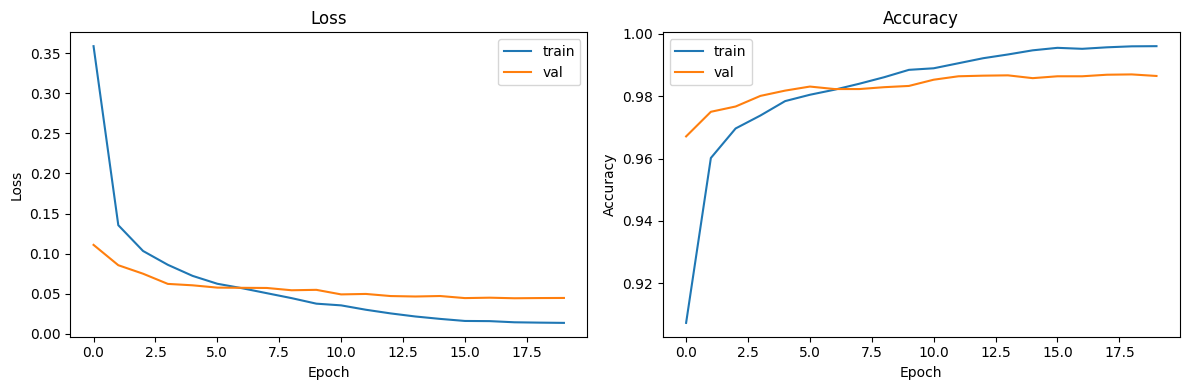

Best val accuracy: 0.9870


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["val_acc"], label="val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()
print(f'Best val accuracy: {max(history["val_acc"]):.4f}')

---
## 8. Inspecting What the Network Learned

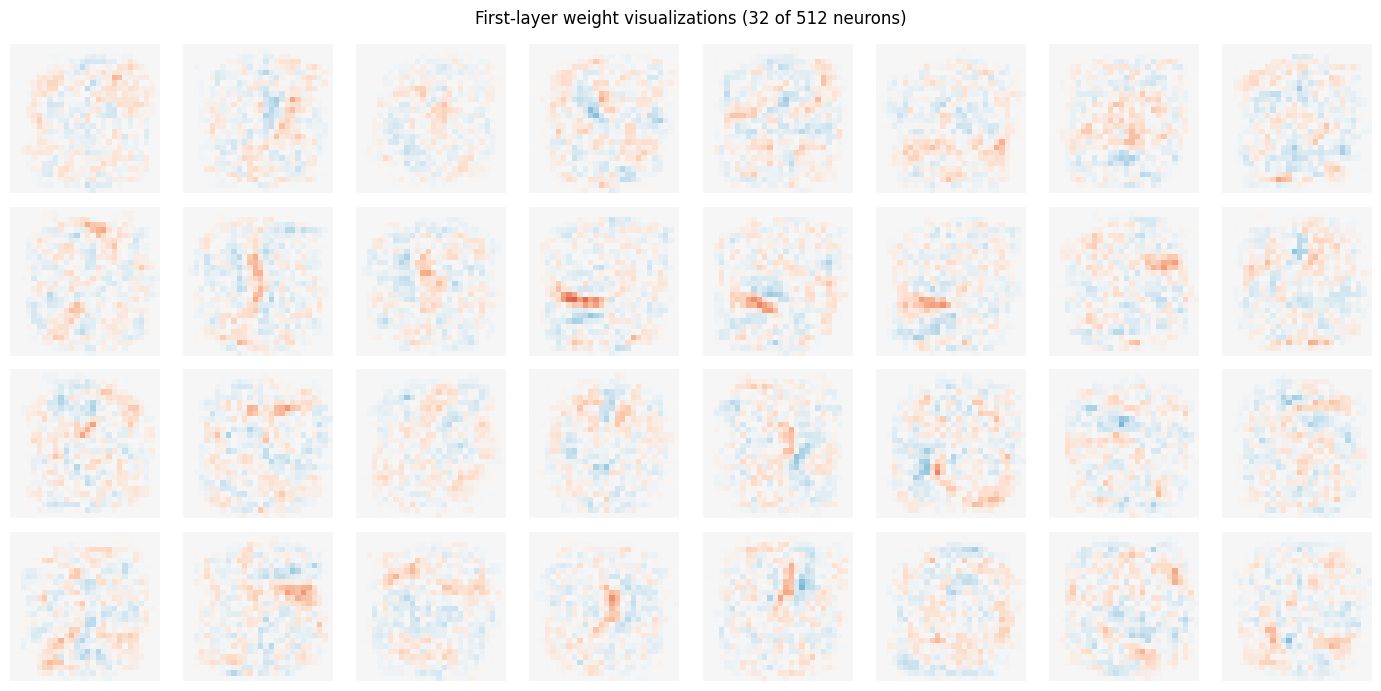

In [ ]:
# Visualize first-layer weights as 28x28 images
first_layer = model.net[0]  # nn.Linear(784, 512)
weights = first_layer.weight.detach().cpu()  # (512, 784)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(weights[i].view(28, 28), cmap="RdBu", vmin=-0.3, vmax=0.3)
    ax.axis("off")
plt.suptitle("First-layer weight visualizations (32 of 512 neurons)")
plt.tight_layout()
plt.show()

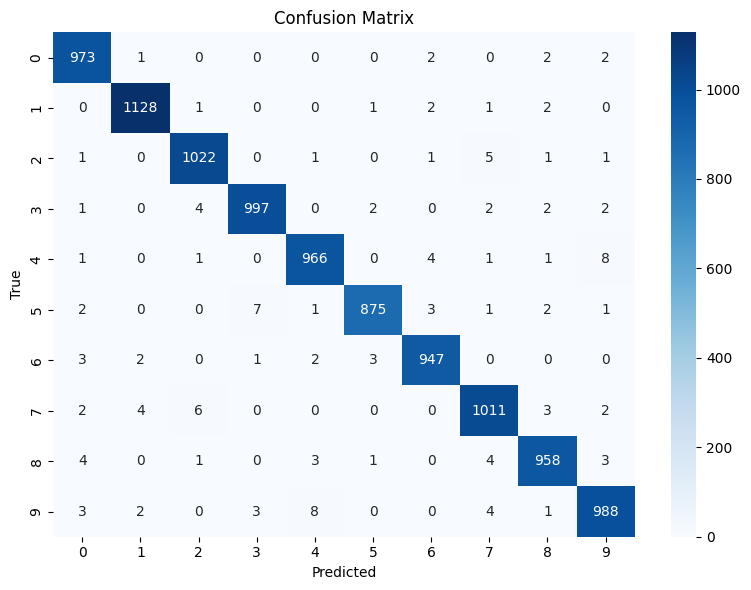

In [ ]:
# Confusion matrix on validation set
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for X, y in val_loader:
        X = X.view(X.size(0), -1).to(device)
        preds = model(X).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_labels.extend(y.tolist())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

---
## 9. Gradient Flow Diagnostics

Inspecting gradient magnitudes per layer reveals vanishing/exploding gradient problems.

In [ ]:
# Run one backward pass and inspect gradients
X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.view(X_batch.size(0), -1).to(device)
y_batch = y_batch.to(device)

model.train()
logits = model(X_batch)
loss = criterion(logits, y_batch)
loss.backward()

print(f'{"Layer":<30} {"Grad mean abs":>15} {"Grad std":>12}')
print("-" * 60)
for name, param in model.named_parameters():
    if param.grad is not None:
        print(
            f"{name:<30} {param.grad.abs().mean().item():>15.2e} {param.grad.std().item():>12.2e}"
        )

Layer                            Grad mean abs     Grad std
------------------------------------------------------------
net.0.weight                          5.36e-04     1.39e-03
net.0.bias                            1.25e-10     2.06e-10
net.1.weight                          2.29e-03     3.32e-03
net.1.bias                            2.61e-03     3.49e-03
net.4.weight                          7.29e-04     1.49e-03
net.4.bias                            2.39e-10     3.70e-10
net.5.weight                          1.61e-03     2.23e-03
net.5.bias                            2.03e-03     2.87e-03
net.8.weight                          8.06e-04     1.24e-03
net.8.bias                            2.40e-10     3.57e-10
net.9.weight                          9.36e-04     1.36e-03
net.9.bias                            2.27e-03     3.19e-03
net.12.weight                         1.91e-03     4.35e-03
net.12.bias                           3.78e-03     6.14e-03


---
## 10. Learning Rate Sensitivity

A quick sweep to demonstrate how LR affects convergence.

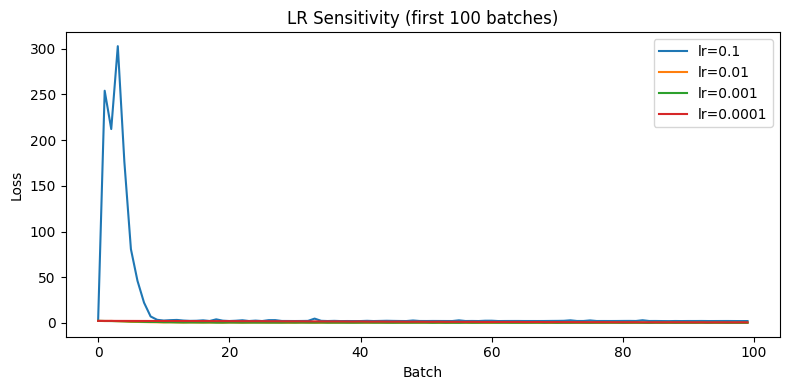

In [ ]:
lrs = [1e-1, 1e-2, 1e-3, 1e-4]
results = {}

for lr in lrs:
    m = make_mlp([784, 256, 128, 10]).to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    losses_lr = []
    m.train()
    for X, y in train_loader:
        X = X.view(X.size(0), -1).to(device)
        y = y.to(device)
        opt.zero_grad()
        loss = criterion(m(X), y)
        loss.backward()
        opt.step()
        losses_lr.append(loss.item())
        if len(losses_lr) >= 100:
            break
    results[lr] = losses_lr

plt.figure(figsize=(8, 4))
for lr, ls in results.items():
    plt.plot(ls, label=f"lr={lr}")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title("LR Sensitivity (first 100 batches)")
plt.legend()
plt.tight_layout()
plt.show()